# 🖊️ Signature Detection & Classification using YOLOv8

This notebook walks through the complete pipeline for building a **Genuine vs. Forged** signature classifier using Ultralytics YOLOv8.

### Steps
1. Environment Setup & Imports
2. Dataset Exploration
3. Dataset Preparation (Train / Val / Test split)
4. Model Training
5. Training Results Visualization
6. Model Evaluation
7. Inference on Test Images
8. Export the Trained Model

---
## Step 1 — Environment Setup & Imports
Install the required packages and import them.

In [1]:
# Install ultralytics (includes YOLOv8)
!pip install ultralytics --quiet

In [2]:
import os
import shutil
import random
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image

from ultralytics import YOLO

print("All imports successful! ✅")

All imports successful! ✅


---
## Step 2 — Dataset Exploration
Let's explore the raw dataset to understand its structure and size.

In [5]:
# === CONFIGURE YOUR PATHS HERE ===
BASE_DIR = r"d:\signature_detection_-_verification\signatures"
ORG_DIR  = os.path.join(BASE_DIR, "full_org")   # Genuine signatures
FORG_DIR = os.path.join(BASE_DIR, "full_forg")   # Forged signatures

# Output directory for the prepared dataset
DATASET_DIR = r"d:\signature_detection_-_verification\datasets\signature_data"

# Count files
org_files  = [f for f in os.listdir(ORG_DIR)  if f.lower().endswith('.png')]
forg_files = [f for f in os.listdir(FORG_DIR) if f.lower().endswith('.png')]

print(f"📂 Genuine signatures (full_org) : {len(org_files)} images")
print(f"📂 Forged  signatures (full_forg): {len(forg_files)} images")
print(f"📊 Total images                  : {len(org_files) + len(forg_files)}")

📂 Genuine signatures (full_org) : 1320 images
📂 Forged  signatures (full_forg): 1320 images
📊 Total images                  : 2640


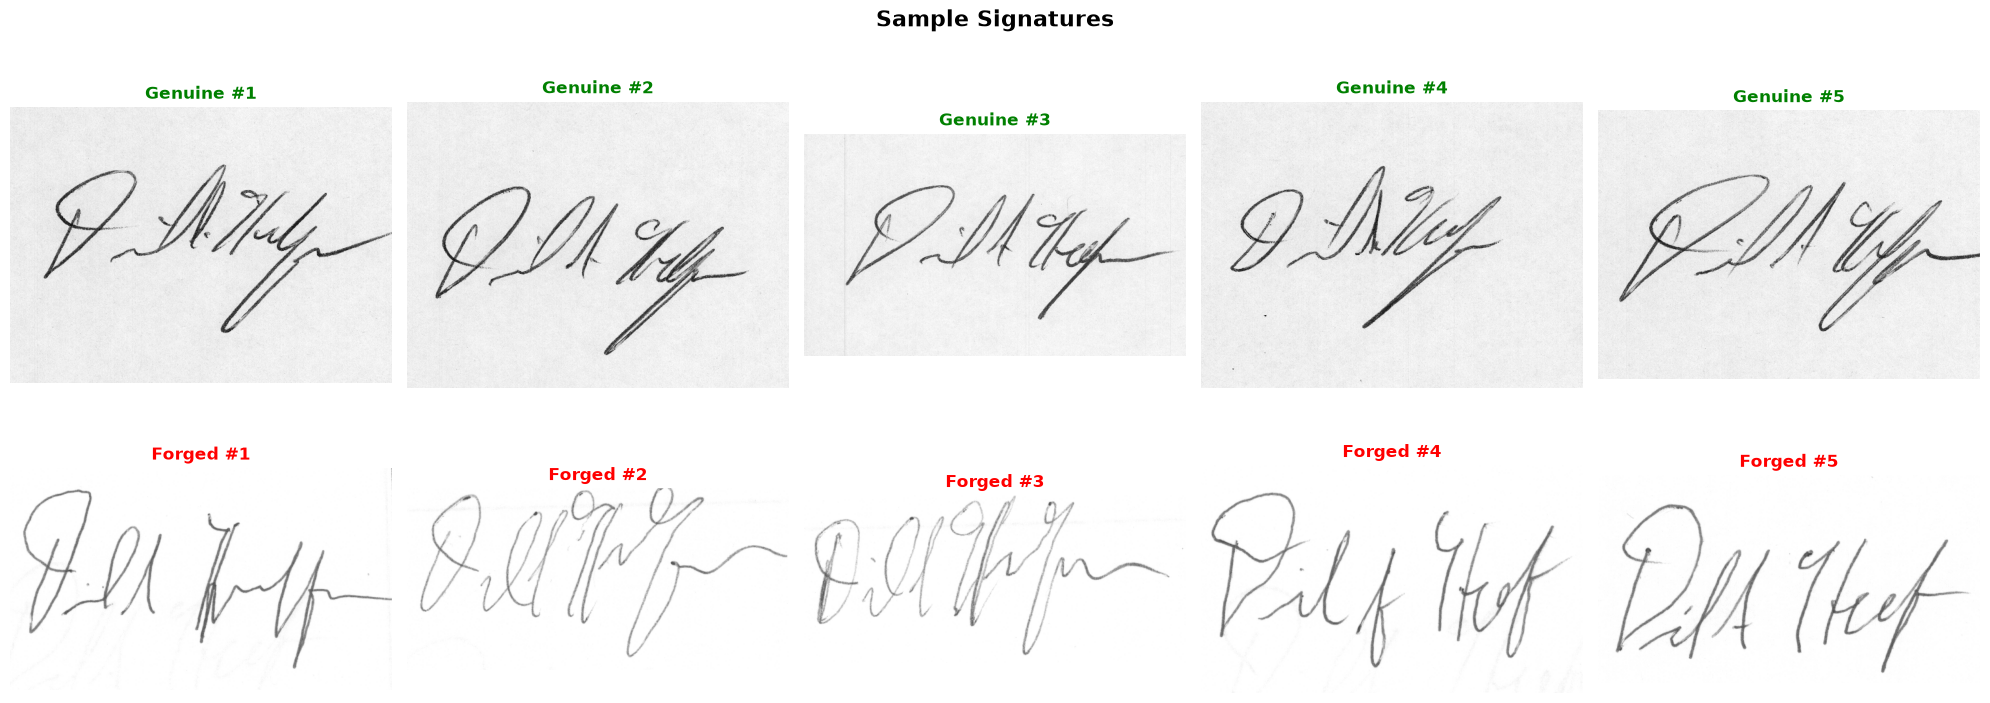

In [6]:
# Visualize a few sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Sample Signatures", fontsize=16, fontweight='bold')

# Show 5 genuine samples
for i, ax in enumerate(axes[0]):
    img_path = os.path.join(ORG_DIR, org_files[i])
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Genuine #{i+1}", color='green', fontweight='bold')
    ax.axis('off')

# Show 5 forged samples
for i, ax in enumerate(axes[1]):
    img_path = os.path.join(FORG_DIR, forg_files[i])
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Forged #{i+1}", color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Check image dimensions for a few samples
print("Sample image dimensions:")
for f in org_files[:3]:
    img = Image.open(os.path.join(ORG_DIR, f))
    print(f"  {f}: {img.size} (W x H), mode={img.mode}")
for f in forg_files[:3]:
    img = Image.open(os.path.join(FORG_DIR, f))
    print(f"  {f}: {img.size} (W x H), mode={img.mode}")

Sample image dimensions:
  original_10_1.png: (534, 385) (W x H), mode=L
  original_10_10.png: (552, 414) (W x H), mode=L
  original_10_11.png: (588, 342) (W x H), mode=L
  forgeries_10_1.png: (618, 360) (W x H), mode=P
  forgeries_10_10.png: (606, 288) (W x H), mode=P
  forgeries_10_11.png: (588, 258) (W x H), mode=P


---
## Step 3 — Dataset Preparation
Reorganize images into the YOLOv8 classification directory format:
```
datasets/signature_data/
├── train/
│   ├── genuine/
│   └── forged/
├── val/
│   ├── genuine/
│   └── forged/
└── test/
    ├── genuine/
    └── forged/
```
We use an **80/10/10** split (Train / Validation / Test).

In [8]:
def prepare_dataset(org_dir, forg_dir, output_dir, seed=42):
    """Split genuine & forged images into train/val/test folders."""
    
    splits  = ["train", "val", "test"]
    classes = ["genuine", "forged"]

    # Create directory structure
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    # Collect image files
    org_files  = sorted([f for f in os.listdir(org_dir)  if f.lower().endswith('.png')])
    forg_files = sorted([f for f in os.listdir(forg_dir) if f.lower().endswith('.png')])

    # Shuffle
    random.seed(seed)
    random.shuffle(org_files)
    random.shuffle(forg_files)

    def split_list(file_list):
        n = len(file_list)
        train_end = int(n * 0.80)
        val_end   = int(n * 0.90)
        return file_list[:train_end], file_list[train_end:val_end], file_list[val_end:]

    org_train, org_val, org_test    = split_list(org_files)
    forg_train, forg_val, forg_test = split_list(forg_files)

    def copy_files(files, source_dir, split, cls):
        dest = os.path.join(output_dir, split, cls)
        for f in files:
            shutil.copy2(os.path.join(source_dir, f), os.path.join(dest, f))
        print(f"  ✅ {split}/{cls}: {len(files)} images")

    print("Copying files...")
    copy_files(org_train,  org_dir,  "train", "genuine")
    copy_files(org_val,    org_dir,  "val",   "genuine")
    copy_files(org_test,   org_dir,  "test",  "genuine")
    copy_files(forg_train, forg_dir, "train", "forged")
    copy_files(forg_val,   forg_dir, "val",   "forged")
    copy_files(forg_test,  forg_dir, "test",  "forged")

    print(f"\n🎉 Dataset prepared at: {output_dir}")

# Run the preparation
prepare_dataset(ORG_DIR, FORG_DIR, DATASET_DIR)

Copying files...
  ✅ train/genuine: 1056 images
  ✅ val/genuine: 132 images
  ✅ test/genuine: 132 images
  ✅ train/forged: 1056 images
  ✅ val/forged: 132 images
  ✅ test/forged: 132 images

🎉 Dataset prepared at: d:\signature_detection_-_verification\datasets\signature_data


In [9]:
# Verify the split counts
print("📊 Dataset Split Summary:")
print("=" * 40)
for split in ["train", "val", "test"]:
    for cls in ["genuine", "forged"]:
        path = os.path.join(DATASET_DIR, split, cls)
        count = len(os.listdir(path))
        print(f"  {split:6s} / {cls:8s} : {count} images")
    print()

📊 Dataset Split Summary:
  train  / genuine  : 1056 images
  train  / forged   : 1056 images

  val    / genuine  : 132 images
  val    / forged   : 132 images

  test   / genuine  : 132 images
  test   / forged   : 132 images



---
## Step 4 — Model Training
Load a pre-trained **YOLOv8 Nano Classification** model and fine-tune it on our dataset.

| Parameter | Value | Description |
|-----------|-------|-------------|
| `model`   | `yolov8n-cls.pt` | Nano variant (smallest, fastest) |
| `epochs`  | 20 | Number of training epochs |
| `imgsz`   | 224 | Input image size |
| `batch`   | 32 | Batch size |

> 💡 **Tip:** You can swap `yolov8n-cls.pt` with `yolov8s-cls.pt` (small) or `yolov8m-cls.pt` (medium) for potentially higher accuracy at the cost of longer training time.

In [10]:
# Load pre-trained YOLOv8 classification model
model = YOLO("yolov8n-cls.pt")

print(f"Model loaded: {model.model_name}")
print("Ready for training! 🚀")

Model loaded: yolov8n-cls.pt
Ready for training! 🚀


In [11]:
# Train the model
results = model.train(
    data=DATASET_DIR,
    epochs=20,
    imgsz=224,
    batch=32,
    project=r"d:\signature_detection_-_verification\runs",
    name="signature_classifier",
    patience=5,          # Early stopping patience
    optimizer="Adam",
    lr0=0.001,           # Initial learning rate
    verbose=True
)

print("\n✅ Training complete!")

New https://pypi.org/project/ultralytics/8.4.88 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.87  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\signature_detection_-_verification\datasets\signature_data, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n

---
## Step 5 — Training Results Visualization
YOLOv8 automatically saves training curves and metrics. Let's visualize them.

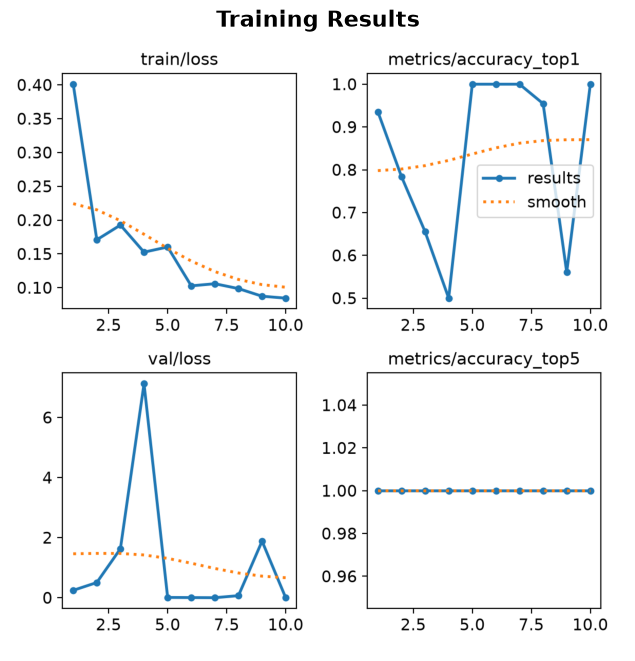

In [12]:
# Find the latest training run directory
train_dir = r"d:\signature_detection_-_verification\runs\signature_classifier"

# Display training results image generated by YOLOv8
results_img_path = os.path.join(train_dir, "results.png")
if os.path.exists(results_img_path):
    img = mpimg.imread(results_img_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Results", fontsize=16, fontweight='bold')
    plt.show()
else:
    print(f"⚠️ results.png not found at {results_img_path}")
    print("  This is normal if training hasn't completed yet.")

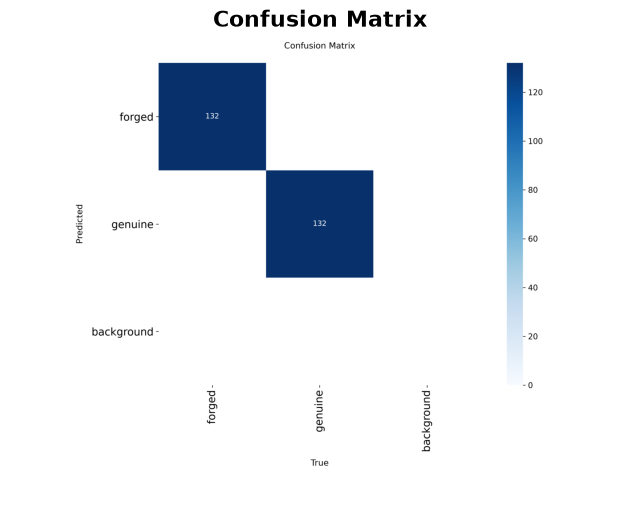

In [13]:
# Display the confusion matrix
confusion_matrix_path = os.path.join(train_dir, "confusion_matrix.png")
if os.path.exists(confusion_matrix_path):
    img = mpimg.imread(confusion_matrix_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix", fontsize=16, fontweight='bold')
    plt.show()
else:
    print(f"⚠️ confusion_matrix.png not found at {confusion_matrix_path}")

---
## Step 6 — Model Evaluation
Evaluate the trained model on the **validation** set to get accuracy metrics.

In [14]:
# Load the best weights from training
best_model_path = os.path.join(train_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

print(f"✅ Loaded best model from: {best_model_path}")

✅ Loaded best model from: d:\signature_detection_-_verification\runs\signature_classifier\weights\best.pt


In [15]:
# Validate on the validation set
val_results = best_model.val(
    data=DATASET_DIR,
    imgsz=224,
    batch=32,
    split="val"
)

print(f"\n📊 Validation Results:")
print(f"  Top-1 Accuracy: {val_results.top1:.4f}")
print(f"  Top-5 Accuracy: {val_results.top5:.4f}")

Ultralytics 8.4.87  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: D:\signature_detection_-_verification\datasets\signature_data\train... found 2112 images in 2 classes  
val: D:\signature_detection_-_verification\datasets\signature_data\val... found 264 images in 2 classes  
test: D:\signature_detection_-_verification\datasets\signature_data\test... found 264 images in 2 classes  
val: Fast image access  (ping: 0.00.0 ms, read: 131.959.3 MB/s, size: 50.0 KB)
val: Scanning D:\signature_detection_-_verification\datasets\signature_data\val... 264 images, 0 corrupt: 100% ━━━━━━━━━━━━ 264/264 79.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 9/9 1.2it/s 7.4s1.1s2
                   all          1          1
Speed: 0.3ms preprocess, 2.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to D:\signature_detection_-_ve

---
## Step 7 — Inference on Test Images
Run the trained model on unseen test images to see predictions.

In [16]:
# Collect test images
test_genuine = glob.glob(os.path.join(DATASET_DIR, "test", "genuine", "*.png"))
test_forged  = glob.glob(os.path.join(DATASET_DIR, "test", "forged",  "*.png"))

# Pick a few samples from each class
sample_genuine = test_genuine[:4]
sample_forged  = test_forged[:4]
sample_images  = sample_genuine + sample_forged
actual_labels  = ["genuine"] * len(sample_genuine) + ["forged"] * len(sample_forged)

print(f"Running inference on {len(sample_images)} test images...")

Running inference on 8 test images...


C:\Users\soumy\AppData\Local\Temp\ipykernel_4928\4170070667.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\soumy\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


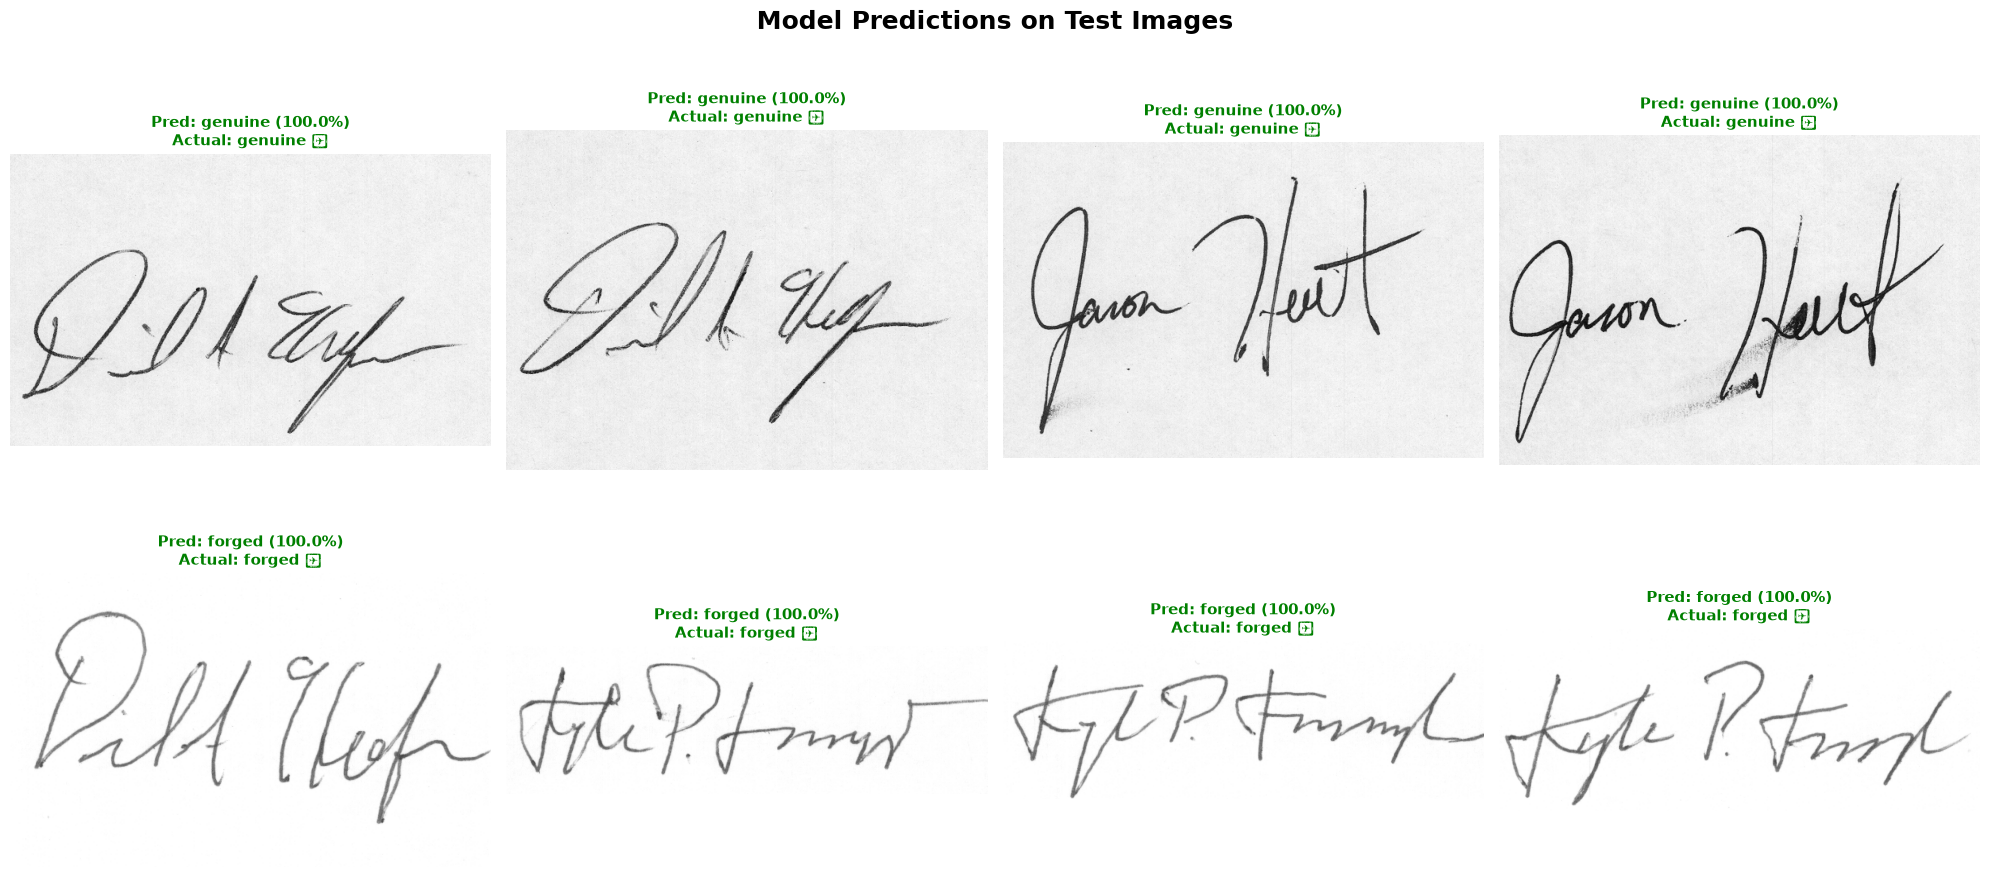

In [17]:
# Run predictions
predictions = best_model.predict(
    source=sample_images,
    imgsz=224,
    verbose=False
)

# Visualize predictions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Model Predictions on Test Images", fontsize=18, fontweight='bold')

for i, (ax, result) in enumerate(zip(axes.flatten(), predictions)):
    img = Image.open(sample_images[i])
    ax.imshow(img, cmap='gray')
    
    # Get predicted class and confidence
    probs = result.probs
    pred_class_id = probs.top1
    pred_class_name = result.names[pred_class_id]
    confidence = probs.top1conf.item()
    actual = actual_labels[i]
    
    # Color code: green if correct, red if wrong
    is_correct = pred_class_name == actual
    color = 'green' if is_correct else 'red'
    status = '✅' if is_correct else '❌'
    
    ax.set_title(
        f"Pred: {pred_class_name} ({confidence:.1%})\nActual: {actual} {status}",
        color=color, fontweight='bold', fontsize=11
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
# Calculate test set accuracy
all_test_images = test_genuine + test_forged
all_actual = ["genuine"] * len(test_genuine) + ["forged"] * len(test_forged)

all_preds = best_model.predict(source=all_test_images, imgsz=224, verbose=False)

correct = 0
total = len(all_preds)

for pred, actual in zip(all_preds, all_actual):
    pred_class = pred.names[pred.probs.top1]
    if pred_class == actual:
        correct += 1

accuracy = correct / total
print(f"\n📊 Test Set Results:")
print(f"  Total images : {total}")
print(f"  Correct      : {correct}")
print(f"  Incorrect    : {total - correct}")
print(f"  Accuracy     : {accuracy:.2%}")


📊 Test Set Results:
  Total images : 264
  Correct      : 264
  Incorrect    : 0
  Accuracy     : 100.00%


---
## Step 8 — Export the Trained Model
Export the model to different formats for deployment.

In [19]:
# Export to ONNX format (widely supported for deployment)
exported_path = best_model.export(format="onnx", imgsz=224)
print(f"\n✅ Model exported to ONNX: {exported_path}")

Ultralytics 8.4.87  Python-3.14.6 torch-2.12.1+cu126 CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)

PyTorch: starting from 'd:\signature_detection_-_verification\runs\signature_classifier\weights\best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 2) (2.8 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.2s, saved as 'd:\signature_detection_-_verification\runs\signature_classifier\weights\best.onnx' (5.5 MB)

Export complete (1.3s)
Results saved to D:\signature_detection_-_verification\runs\signature_classifier\weights\best.onnx
Predict:         yolo predict task=classify model=d:\signature_detection_-_verification\runs\signature_classifier\weights\best.onnx imgsz=224 
Validate:        yolo val task=classify model=d:\signature_detection_-_verification\runs\signature_classifier\weights\best.onnx imgsz=224 data=d:\signature_detection_-_verification\datasets\signature_data  
Visualize:       https://n

In [20]:
# You can also export to other formats:
# best_model.export(format="torchscript")  # PyTorch TorchScript
# best_model.export(format="tflite")        # TensorFlow Lite (mobile)
# best_model.export(format="engine")        # TensorRT (NVIDIA GPUs)

print("\n🎉 All done! Your signature classifier is trained and ready.")
print(f"\n📁 Best weights saved at:")
print(f"   {best_model_path}")


🎉 All done! Your signature classifier is trained and ready.

📁 Best weights saved at:
   d:\signature_detection_-_verification\runs\signature_classifier\weights\best.pt


---
## 🔮 Using the Model for New Predictions
After training, you can load the model and classify any new signature image:

In [21]:
# ==========================================
# Quick Usage - Classify a new signature
# ==========================================
# 
# from ultralytics import YOLO
# 
# model = YOLO(r"d:\signature_detection_-_verification\runs\signature_classifier\weights\best.pt")
# result = model.predict("path/to/new_signature.png", imgsz=224)
# 
# pred_class = result[0].names[result[0].probs.top1]
# confidence = result[0].probs.top1conf.item()
# print(f"Prediction: {pred_class} (confidence: {confidence:.2%})")

print("Uncomment the code above and provide a path to classify a new signature.")

Uncomment the code above and provide a path to classify a new signature.
